In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay


In [ ]:
engine = create_engine(
    "mysql+pymysql://root:pw@localhost/churn_project"
)

df = pd.read_sql("SELECT * FROM model_features", engine)

In [11]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,city,contract_type,payment_method,monthly_charges,total_charges,has_internet,num_services,churn_value,churn_score,cltv
0,0002-ORFBO,Female,0,1,0,9,Frazier Park,One year,Mailed check,65.6,593.30,1,2.0,0,65,2205.0
1,0003-MKNFE,Male,0,0,0,9,Glendale,Month-to-month,Mailed check,59.9,542.40,1,2.0,0,66,5414.0
2,0004-TLHLJ,Male,0,0,0,4,Costa Mesa,Month-to-month,Electronic check,73.9,280.85,1,2.0,1,71,4479.0
3,0011-IGKFF,Male,1,1,0,13,Martinez,Month-to-month,Electronic check,98.0,1237.85,1,2.0,1,99,3714.0
4,0013-EXCHZ,Female,1,1,0,3,Camarillo,Month-to-month,Mailed check,83.9,267.40,1,2.0,1,68,3464.0


In [5]:
num_cols = [
    "senior_citizen",
    "partner",
    "dependents",
    "tenure_months",
    "monthly_charges",
    "total_charges",
    "has_internet",
    "num_services",
    "churn_score",
    "cltv"
]

cat_cols = [
    "gender",
    "city",
    "contract_type",
    "payment_method"
]

X = df[num_cols + cat_cols]

y = df["churn_value"]




In [6]:
numeric_transformer = Pipeline([
    ("Scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("Onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [7]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [8]:
model = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier())
])

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [11]:
y_pred = model.predict(X_test)

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1033
           1       0.90      0.84      0.87       374

    accuracy                           0.93      1407
   macro avg       0.92      0.90      0.91      1407
weighted avg       0.93      0.93      0.93      1407



In [13]:
y_proba = model.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ROC-AUC: 0.9820935854760808


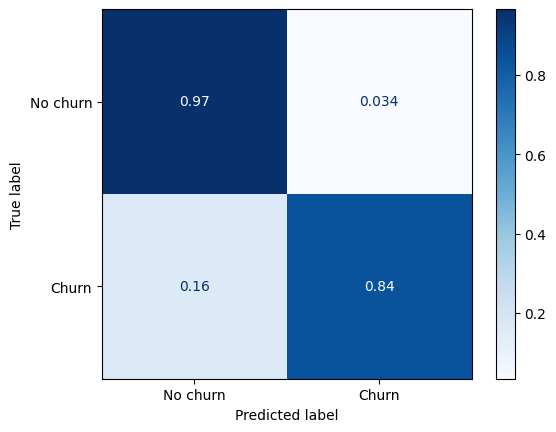

In [14]:
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["No churn", "Churn"])
disp.plot(cmap="Blues")

In [15]:
df["churn_probability"] = model.predict_proba(X)[:,1]
df["predicted_on"] = pd.Timestamp.now()

In [64]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure_months,city,contract_type,payment_method,monthly_charges,...,has_internet,num_services,churn_value,churn_score,cltv,churn_probability,risk_segment,estimated_revenue_at_risk,predicted_on,model_name
0,0002-ORFBO,Female,0,1,0,9,Frazier Park,One year,Mailed check,65.6,...,1,2.0,0,65,2205.0,0.046142,Low,3.026926,2026-03-21 12:19:42.029402,XGBoost
1,0003-MKNFE,Male,0,0,0,9,Glendale,Month-to-month,Mailed check,59.9,...,1,2.0,0,66,5414.0,0.348708,Low,20.887597,2026-03-21 12:19:42.029402,XGBoost
2,0004-TLHLJ,Male,0,0,0,4,Costa Mesa,Month-to-month,Electronic check,73.9,...,1,2.0,1,71,4479.0,0.845722,High,62.498840,2026-03-21 12:19:42.029402,XGBoost
3,0011-IGKFF,Male,1,1,0,13,Martinez,Month-to-month,Electronic check,98.0,...,1,2.0,1,99,3714.0,0.999877,High,97.987955,2026-03-21 12:19:42.029402,XGBoost
4,0013-EXCHZ,Female,1,1,0,3,Camarillo,Month-to-month,Mailed check,83.9,...,1,2.0,1,68,3464.0,0.945103,High,79.294166,2026-03-21 12:19:42.029402,XGBoost


In [16]:
def risk_segment(p):
    if p > 0.7:
        return "High"
    elif p > 0.4:
        return "Medium"
    else:
        return "Low"

df["risk_segment"] = df["churn_probability"].apply(risk_segment)

In [17]:
df["estimated_revenue_at_risk"] = df["monthly_charges"] * df["churn_probability"]
df["model_name"] = "XGBoost"

In [18]:
predictions = df[
    ["customer_id", "churn_probability", "risk_segment", "estimated_revenue_at_risk", "predicted_on", "model_name"]
]

predictions.to_sql(
    "predictions",
    engine,
    if_exists="append",
    index=False,
    chunksize=1000,
    method="multi"
)

7032

In [19]:
predictions.to_csv("predictions.csv")